In [1]:
import tensorflow as tf
import os
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras import layers, models
import tensorflow.keras

In [2]:
train_dataset_path = "SPLIT FULL 16K 32/train"
val_dataset_path = "SPLIT FULL 16K 32/val"
test_dataset_path = "SPLIT FULL 16K 32/test"

In [3]:
image_height, image_width = 32, 32
batch_size = 128

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  train_dataset_path,
  seed=123,
  image_size=(image_height, image_width),
  batch_size=batch_size,
  labels="inferred",
  label_mode="categorical",
  color_mode="grayscale",)

val_ds = tf.keras.utils.image_dataset_from_directory(
  val_dataset_path,
  seed=456,
  image_size=(image_height, image_width),
  batch_size=batch_size,
  labels="inferred",
  label_mode="categorical",
  color_mode="grayscale",)

test_ds = tf.keras.utils.image_dataset_from_directory(
  test_dataset_path,
  seed=789,
  image_size=(image_height, image_width),
  batch_size=batch_size,
  labels="inferred",
  label_mode="categorical",
  color_mode="grayscale",)

class_names = train_ds.class_names
print("Class names:", class_names)   # ← e.g. ['cat', 'dog', 'panda']

Found 25200 files belonging to 4 classes.
Found 3600 files belonging to 4 classes.
Found 7200 files belonging to 4 classes.
Class names: ['S1 NIC', 'S2 IAN', 'S3 SHE', 'S4 PEN']


In [5]:
# Option A: using a layer (recommended for most people)
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(  lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(  lambda x, y: (normalization_layer(x), y))

Training images count   : 197 batches → ~25216 images
Validation images count : 29 batches → ~3712 images
Test images count       : 57 batches → ~7296 images
Shape of one training batch  → images: (128, 32, 32, 1), labels: (128, 4)


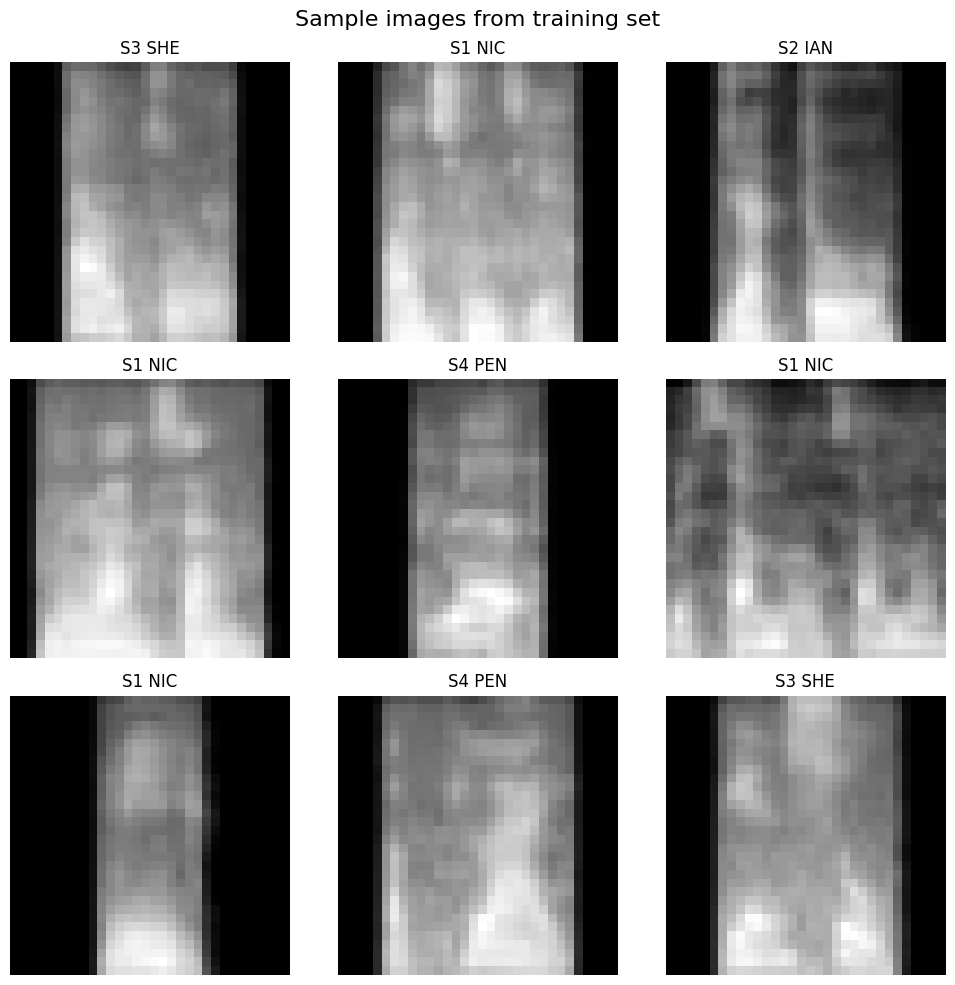

In [6]:
print(f"Training images count   : {train_ds.cardinality().numpy()} batches "
      f"→ ~{train_ds.cardinality().numpy() * batch_size} images")

print(f"Validation images count : {val_ds.cardinality().numpy()} batches "
      f"→ ~{val_ds.cardinality().numpy() * batch_size} images")

print(f"Test images count       : {test_ds.cardinality().numpy()} batches "
      f"→ ~{test_ds.cardinality().numpy() * batch_size} images")

# If you really want to see the shape of one batch (most useful debug info):
for images, labels in train_ds.take(1):
    print(f"Shape of one training batch  → images: {images.shape}, labels: {labels.shape}")
    # Example output: images: (32, 224, 224, 1), labels: (32, num_classes)
    break

# Same for validation / test if you want
# for images, labels in val_ds.take(1): ...

# ────────────────────────────────────────────────
#  Display 9 example images from the training set
# ────────────────────────────────────────────────

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):          # take 1 batch
    for i in range(9):                           # show first 9 images
        ax = plt.subplot(3, 3, i + 1)
        
        # Grayscale → squeeze channel dimension for imshow
        img = images[i].numpy().squeeze()       # shape becomes (h, w)
        
        plt.imshow(img, cmap='gray')             # important: use cmap='gray'
        # plt.imshow(images[i].numpy().astype("uint8"))  ← only if you already rescaled to [0,255]
        
        # Get predicted class index and convert to name
        label_idx = np.argmax(labels[i])         # because label_mode='categorical'
        plt.title(class_names[label_idx])
        plt.axis("off")

plt.suptitle("Sample images from training set", fontsize=16)
plt.tight_layout()
plt.show()

In [6]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 1)),   # CNN needs channel dimension

    layers.Conv2D(16, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(4, activation='softmax')
])

In [7]:
model.compile(optimizer='adam', loss=tf.losses.CategoricalCrossentropy(), metrics=['accuracy'])

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         131,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 136,196 (532.02 KB)

 Trainable params: 136,196 (532.02 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
import time
# Start timer
start_time = time.time()

In [10]:
hist = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50, 
    )

Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.5887 - loss: 0.9859 - val_accuracy: 0.7647 - val_loss: 0.6165
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8142 - loss: 0.4922 - val_accuracy: 0.8639 - val_loss: 0.3781
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8715 - loss: 0.3497 - val_accuracy: 0.8886 - val_loss: 0.3021
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8935 - loss: 0.2892 - val_accuracy: 0.8808 - val_loss: 0.3145
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.9009 - loss: 0.2641 - val_accuracy: 0.9133 - val_loss: 0.2338
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9140 - loss: 0.2366 - val_accuracy: 0.9183 - val_loss: 0.2287
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9199 - loss: 0.2146 - val_accuracy: 0.9297 - val_loss: 0.1935
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9248 - loss: 0.2000 - val_accu

In [11]:
# End timer
end_time = time.time()

# Calculate elapsed time
elapsed_time = end_time - start_time
print(f"Training time: {elapsed_time:.2f} seconds")

Training time: 315.19 seconds


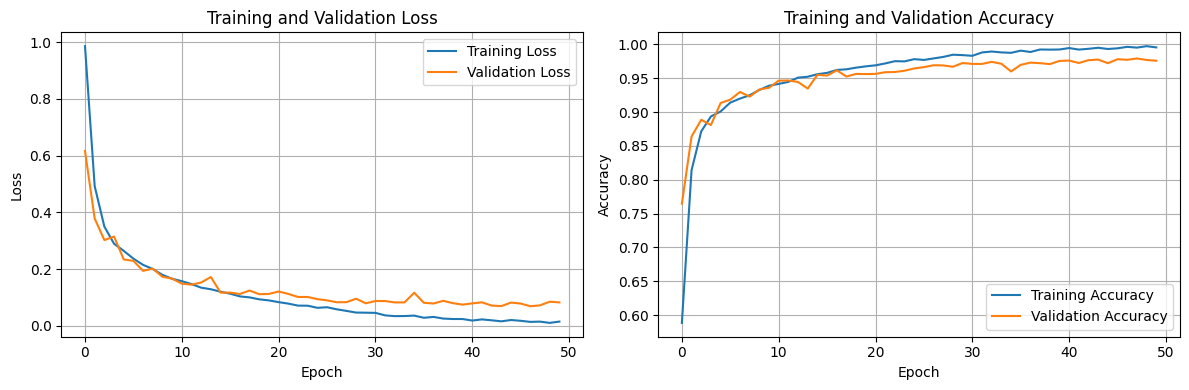

In [12]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist.history['loss'], label='Training Loss')
ax1.plot(hist.history['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(hist.history['accuracy'], label='Training Accuracy')
ax2.plot(hist.history['val_accuracy'], label='Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("cnn_training_history.png", dpi=300)
plt.show()

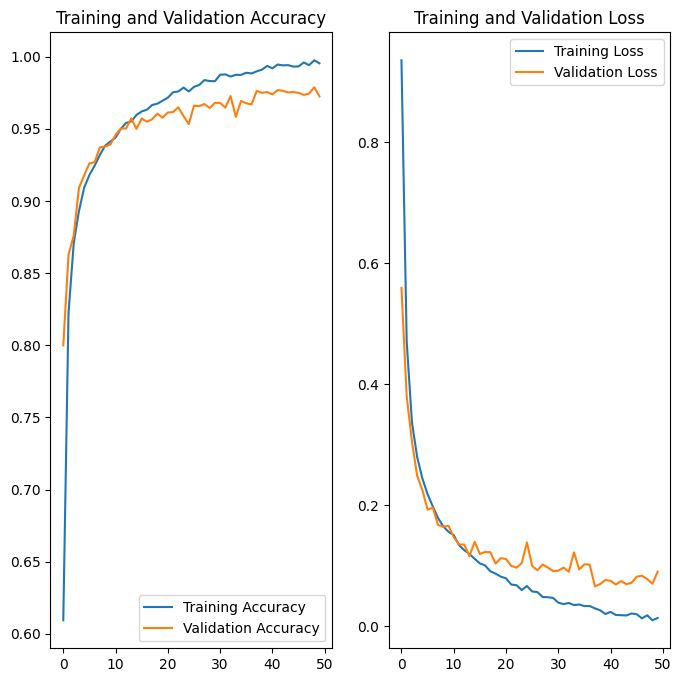

In [12]:
acc = hist.history['accuracy']
val_acc = hist.history['val_accuracy']

loss = hist.history['loss']
val_loss = hist.history['val_loss']

epochs_range = range(50)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [13]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"\nTest accuracy: {test_accuracy:.4f}")

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9731 - loss: 0.0882

Test accuracy: 0.9731


In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [22]:
y_true = []
y_pred = []

for images, labels in test_ds:
    # Store true labels (convert from one-hot to integer index)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    
    # Get model predictions
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

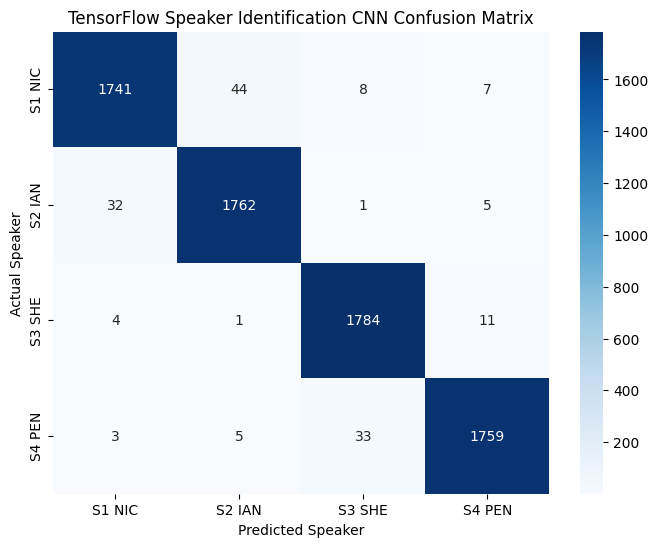

              precision    recall  f1-score   support

      S1 NIC       0.98      0.97      0.97      1800
      S2 IAN       0.97      0.98      0.98      1800
      S3 SHE       0.98      0.99      0.98      1800
      S4 PEN       0.99      0.98      0.98      1800

    accuracy                           0.98      7200
   macro avg       0.98      0.98      0.98      7200
weighted avg       0.98      0.98      0.98      7200



In [23]:
# 2. Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.xlabel('Predicted Speaker')
plt.ylabel('Actual Speaker')
plt.title('TensorFlow Speaker Identification CNN Confusion Matrix')
plt.savefig("cnn_tf_cm.png", dpi=300)
plt.show()

# 4. Print detailed report (Precision, Recall, F1-Score)
print(classification_report(y_true, y_pred, target_names=class_names))

In [17]:
model_config = model.get_config()
model_config

{'name': 'sequential',
 'trainable': True,
 'dtype': {'module': 'keras',
  'class_name': 'DTypePolicy',
  'config': {'name': 'float32'},
  'registered_name': None},
 'layers': [{'module': 'keras.layers',
   'class_name': 'InputLayer',
   'config': {'batch_shape': (None, 32, 32, 1),
    'dtype': 'float32',
    'sparse': False,
    'ragged': False,
    'name': 'input_layer',
    'optional': False},
   'registered_name': None},
  {'module': 'keras.layers',
   'class_name': 'Conv2D',
   'config': {'name': 'conv2d',
    'trainable': True,
    'dtype': {'module': 'keras',
     'class_name': 'DTypePolicy',
     'config': {'name': 'float32'},
     'registered_name': None},
    'filters': 16,
    'kernel_size': (3, 3),
    'strides': (1, 1),
    'padding': 'same',
    'data_format': 'channels_last',
    'dilation_rate': (1, 1),
    'groups': 1,
    'activation': 'relu',
    'use_bias': True,
    'kernel_initializer': {'module': 'keras.initializers',
     'class_name': 'GlorotUniform',
     'con

In [18]:
print(f"Original model parameters: {model.count_params():,}")

Original model parameters: 136,196


In [19]:
save_dir = "CNN model"
os.makedirs(save_dir, exist_ok=True)  # creates folder if not exist

model.save(os.path.join(save_dir, "tensorflow_cnn.keras"))

In [20]:
# model.save('tensorflow_cnn.keras')

In [21]:
# print(f"Tensorflowlite model size: {len(model):,} bytes ({len(model)/1024:.2f} KB)")

In [22]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

In [23]:
tflite_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp_wn3qota\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp_wn3qota\assets


Saved artifact at 'C:\Users\User\AppData\Local\Temp\tmp_wn3qota'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  2719035660752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035661520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035662288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035660560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035661904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035661712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035662480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035663248: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [24]:
tflite_path = os.path.join(save_dir, "tensorflowlite_cnn.tflite")

with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

In [25]:
# with open('tensorflowlite_cnn.tflite', 'wb') as f:
#   f.write(tflite_model)

In [26]:
print(f"Original Tensorflowlite model size: {len(tflite_model):,} bytes ({len(tflite_model)/1024:.2f} KB)")

Original Tensorflowlite model size: 548,888 bytes (536.02 KB)


In [24]:
TF_MODEL_FILE_PATH = 'CNN model/tensorflowlite_cnn.tflite' # The default path to the saved TensorFlow Lite model

from ai_edge_litert.interpreter import Interpreter

interpreter = Interpreter(model_path=TF_MODEL_FILE_PATH)

In [25]:
interpreter.get_signature_list()

{'serving_default': {'inputs': ['keras_tensor'], 'outputs': ['output_0']}}

In [26]:
classify_lite = interpreter.get_signature_runner('serving_default')
classify_lite

In [27]:
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [28]:
print("Input Shape:", input_details[0]['shape'])
print("Output Shape:", output_details[0]['shape'])

Input Shape: [ 1 32 32  1]
Output Shape: [1 4]


In [29]:
y_true_lite = []
y_pred_lite = []

for images, labels in test_ds:
    # Store true labels (convert from one-hot to integer index)
    y_true_lite.extend(np.argmax(labels.numpy(), axis=1))
    
    # Get model predictions
    outputs = classify_lite(keras_tensor=images)
    predictions_lite = outputs['output_0']
    y_pred_lite.extend(np.argmax(predictions_lite, axis=1))

y_true_lite = np.array(y_true_lite)
y_pred_lite = np.array(y_pred_lite)

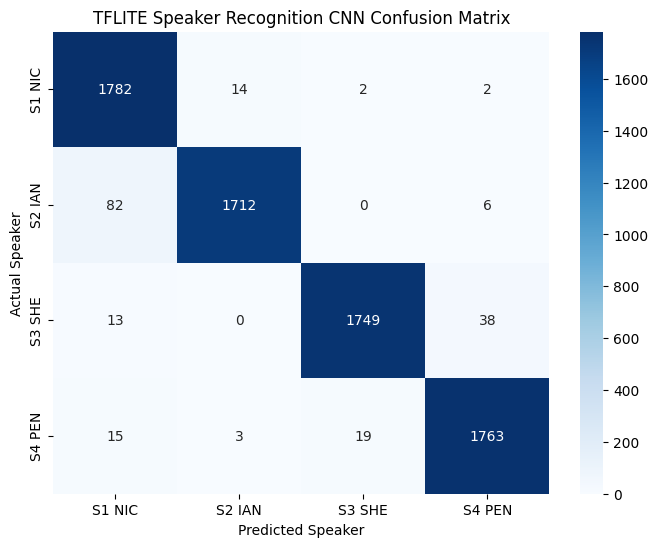

              precision    recall  f1-score   support

      S1 NIC       0.94      0.99      0.97      1800
      S2 IAN       0.99      0.95      0.97      1800
      S3 SHE       0.99      0.97      0.98      1800
      S4 PEN       0.97      0.98      0.98      1800

    accuracy                           0.97      7200
   macro avg       0.97      0.97      0.97      7200
weighted avg       0.97      0.97      0.97      7200



In [30]:
# 2. Create the confusion matrix
cm = confusion_matrix(y_true_lite, y_pred_lite)

# 3. Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.xlabel('Predicted Speaker')
plt.ylabel('Actual Speaker')
plt.title('TFLITE Speaker Recognition CNN Confusion Matrix')
plt.savefig("cnn_tflite_cm.png", dpi=300)
plt.show()

# 4. Print detailed report (Precision, Recall, F1-Score)
print(classification_report(y_true_lite, y_pred_lite, target_names=class_names))

In [34]:
converter.optimizations = [tf.lite.Optimize.DEFAULT]

In [35]:
tflite_quant_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp_250twx5\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp_250twx5\assets


Saved artifact at 'C:\Users\User\AppData\Local\Temp\tmp_250twx5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  2719035660752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035661520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035662288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035660560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035661904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035661712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035662480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035663248: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [36]:
print(f"Quantized Tensorflowlite model size: {len(tflite_quant_model):,} bytes ({len(tflite_quant_model)/1024:.2f} KB)")

Quantized Tensorflowlite model size: 142,944 bytes (139.59 KB)


In [37]:
converter.optimizations = [tf.lite.Optimize.DEFAULT]

In [38]:
def representative_dataset():
    for images, _ in train_ds.take(100):     # or test_ds / val_ds
        yield [images]                       # images already has shape (batch_size, h, w, 1)

In [39]:
def representative_dataset_gen():
    # Use test_ds or val_ds — preferably not train_ds
    # .take(100–300) is usually enough; more is better but slower
    for images, _ in test_ds.take(200):           # ignore labels
        # images shape: (batch_size, h, w, 1)
        # We yield one sample at a time → batch size becomes 1
        for i in range(images.shape[0]):
            single_image = images[i:i+1]          # shape (1, h, w, 1)
            yield [single_image]                  # list of one tensor

In [40]:
converter.representative_dataset = representative_dataset_gen

In [41]:
int_floatback_tflite_model_quant = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpy74u6yjh\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpy74u6yjh\assets


Saved artifact at 'C:\Users\User\AppData\Local\Temp\tmpy74u6yjh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  2719035660752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035661520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035662288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035660560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035661904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035661712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035662480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035663248: TensorSpec(shape=(), dtype=tf.resource, name=None)


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [42]:
interpreter = Interpreter(model_content=int_floatback_tflite_model_quant)
input_type = interpreter.get_input_details()[0]['dtype']
print('input: ', input_type)
output_type = interpreter.get_output_details()[0]['dtype']
print('output: ', output_type)

input:  <class 'numpy.float32'>
output:  <class 'numpy.float32'>


In [43]:
print(f"Integer with floatback Quantized Tensorflowlite model size: {len(int_floatback_tflite_model_quant):,} bytes ({len(int_floatback_tflite_model_quant)/1024:.2f} KB)")

Integer with floatback Quantized Tensorflowlite model size: 144,160 bytes (140.78 KB)


In [44]:
tflite_path = os.path.join(save_dir, 'quantized_tensorflowlite_cnn.tflite')

with open(tflite_path, 'wb') as f:
    f.write(int_floatback_tflite_model_quant)

In [45]:
# with open('quantized_tensorflowlite_cnn.tflite', 'wb') as f:
#   f.write(int_floatback_tflite_model_quant)

In [46]:
zero_arr = np.zeros((32,32), dtype=np.float32)
test_arr = np.full((32,32), 255)
test_arr = test_arr.astype(np.float32) / 255.0

In [47]:
test_arr

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], shape=(32, 32), dtype=float32)

In [31]:
TF_MODEL_FILE_PATH = 'CNN model/quantized_tensorflowlite_cnn.tflite' # The default path to the saved TensorFlow Lite model

from ai_edge_litert.interpreter import Interpreter

interpreter = Interpreter(model_path=TF_MODEL_FILE_PATH)

In [32]:
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [50]:
img = test_arr   # shape (28, 28)
print(img.nbytes)
img = np.expand_dims(img, axis=-1)
print(img.nbytes)
img = np.expand_dims(img, axis=0)    # (1, 28, 28, 1)
print(img.nbytes)

4096
4096
4096


In [51]:
interpreter.allocate_tensors()
interpreter.set_tensor(input_details[0]['index'], img)
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])[0]

In [52]:
predicted_label = np.argmax(output_data)
print("Predicted label:", predicted_label)

Predicted label: 3


In [53]:
# Method 1: Simple & Clean (Recommended)
confidence = output_data[predicted_label]          # raw score of the winning class

print(f"Predicted label : {predicted_label}")
print(f"Confidence      : {confidence:.4f} ({confidence*100:.2f}%)")

# Method 2: Show Top 3 predictions with confidence (Very Useful!)
top3_indices = np.argsort(output_data)[-3:][::-1]   # Get top 3 highest scores

print("\nTop 3 Predictions:")
for idx in top3_indices:
    conf = output_data[idx]
    print(f"  Digit {idx}: {conf:.4f} ({conf*100:.2f}%)")

Predicted label : 3
Confidence      : 0.7461 (74.61%)

Top 3 Predictions:
  Digit 3: 0.7461 (74.61%)
  Digit 2: 0.2539 (25.39%)
  Digit 1: 0.0000 (0.00%)


In [54]:
def print_model_details(model_content, model_name="Model"):
    """Print detailed information about a TFLite model including data types."""
    # For model inspection, we'll use TFLite since TFLM doesn't expose tensor details
    # TFLM is designed for inference, not model introspection
    interpreter = Interpreter(model_content=model_content)
    interpreter.allocate_tensors()
    
    print(f"\n{model_name} Details:")
    print("="*50)
    
    # Get tensor details
    tensor_details = interpreter.get_tensor_details()
    
    # Print input details
    input_details = interpreter.get_input_details()
    print("\nINPUT TENSORS:")
    for inp in input_details:
        tensor = tensor_details[inp['index']]
        print(f"  Name: {tensor['name']}")
        print(f"  Shape: {tensor['shape']}")
        print(f"  Type: {tensor['dtype']}")
        if 'quantization' in tensor and tensor['quantization'][0] != 0:
            print(f"  Quantization: scale={tensor['quantization'][0]:.6f}, zero_point={tensor['quantization'][1]}")
        print()
    
    # Print output details
    output_details = interpreter.get_output_details()
    print("OUTPUT TENSORS:")
    for out in output_details:
        tensor = tensor_details[out['index']]
        print(f"  Name: {tensor['name']}")
        print(f"  Shape: {tensor['shape']}")
        print(f"  Type: {tensor['dtype']}")
        if 'quantization' in tensor and tensor['quantization'][0] != 0:
            print(f"  Quantization: scale={tensor['quantization'][0]:.6f}, zero_point={tensor['quantization'][1]}")
        print()
    
    # Print layer information
    print("ALL LAYERS:")
    print(f"{'Index':<6} {'Name':<40} {'Type':<10} {'Shape':<20} {'Quantization':<30}")
    print("-"*110)
    
    for i, tensor in enumerate(tensor_details):
        quant_info = ""
        if 'quantization' in tensor and tensor['quantization'][0] != 0:
            quant_info = f"s={tensor['quantization'][0]:.4f}, zp={tensor['quantization'][1]}"
        
        print(f"{i:<6} {tensor['name'][:39]:<40} {str(tensor['dtype']):<10} {str(tensor['shape']):<20} {quant_info:<30}")

# Print details for both models
print_model_details(tflite_model, "Original Float32 Model")
print_model_details(int_floatback_tflite_model_quant, "Quantized INT8 Model")


Original Float32 Model Details:

INPUT TENSORS:
  Name: serving_default_keras_tensor:0
  Shape: [ 1 32 32  1]
  Type: <class 'numpy.float32'>

OUTPUT TENSORS:
  Name: StatefulPartitionedCall_1:0
  Shape: [1 4]
  Type: <class 'numpy.float32'>

ALL LAYERS:
Index  Name                                     Type       Shape                Quantization                  
--------------------------------------------------------------------------------------------------------------
0      serving_default_keras_tensor:0           <class 'numpy.float32'> [ 1 32 32  1]                                      
1      arith.constant                           <class 'numpy.float32'> [64]                                               
2      arith.constant1                          <class 'numpy.float32'> [32]                                               
3      arith.constant2                          <class 'numpy.float32'> [4]                                                
4      arith.constant3    

In [33]:
# ────────────────────────────────────────────────────────────────
#  Configuration – change these as needed
# ────────────────────────────────────────────────────────────────

# Path to your LiteRT / TFLite model files
FLOAT_MODEL_PATH   = 'CNN model/tensorflowlite_cnn.tflite'              # original float32 model
QUANT_MODEL_PATH   = 'CNN model/quantized_tensorflowlite_cnn.tflite'         # your quantized model

# Assume test_ds is already created (from image_dataset_from_directory)
# and class_names = test_ds.class_names is available

# Number of samples to evaluate (for speed; set to None to use full test set)
MAX_SAMPLES = None

# ────────────────────────────────────────────────────────────────
#  Helper function to evaluate one LiteRT model
# ────────────────────────────────────────────────────────────────
def evaluate_litert_model(model_path, test_dataset, max_samples=None):
    """
    Evaluate a .tflite / LiteRT model using signature runner.
    Returns: y_true, y_pred (as numpy arrays)
    """

    # Load model
    interpreter = Interpreter(model_path=model_path)
    
    # Get available signatures (usually 'serving_default')
    signatures = interpreter.get_signature_list()
    if 'serving_default' not in signatures:
        raise ValueError("Model does not have 'serving_default' signature")
    
    # Get runner for default inference signature
    runner = interpreter.get_signature_runner('serving_default')
    
    # Get input/output tensor names (usually 'keras_tensor' / 'input_...' and 'output_...')
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    print(f"Model: {model_path}")
    print("Input shape:", input_details[0]['shape'])
    print("Output shape:", output_details[0]['shape'])
    print("-" * 50)

    y_true = []
    y_pred = []
    total_processed = 0

    for images, labels in test_dataset:
        if max_samples is not None and total_processed >= max_samples:
            break

        batch_size = images.shape[0]

        # Run batched inference using signature runner
        # Input key is usually 'keras_tensor' or 'input_1' — adjust if needed
        inputs = {'keras_tensor': images.numpy()}   # ← most common key in recent exports
        outputs = runner(**inputs)
        
        # Output key is usually 'output_0' or 'dense' — adjust based on your model
        predictions = outputs['output_0']           # shape: (batch_size, num_classes)

        # Convert to class indices
        true_classes = np.argmax(labels.numpy(), axis=1)
        pred_classes = np.argmax(predictions, axis=1)

        y_true.extend(true_classes)
        y_pred.extend(pred_classes)

        total_processed += batch_size
        print(f"Processed {total_processed} samples...", end='\r')

    print(f"\nEvaluated {len(y_true)} samples")
    return np.array(y_true), np.array(y_pred)


Evaluating FLOAT model...
Model: CNN model/tensorflowlite_cnn.tflite
Input shape: [ 1 32 32  1]
Output shape: [1 4]
--------------------------------------------------
Processed 7200 samples...
Evaluated 7200 samples

Evaluating QUANTIZED model...
Model: CNN model/quantized_tensorflowlite_cnn.tflite
Input shape: [ 1 32 32  1]
Output shape: [1 4]
--------------------------------------------------
Processed 7200 samples...
Evaluated 7200 samples

MODEL ACCURACY COMPARISON
Float model    : 0.9731  (97.31%)
Quantized model: 0.9704  (97.04%)
Accuracy drop  : 0.26%


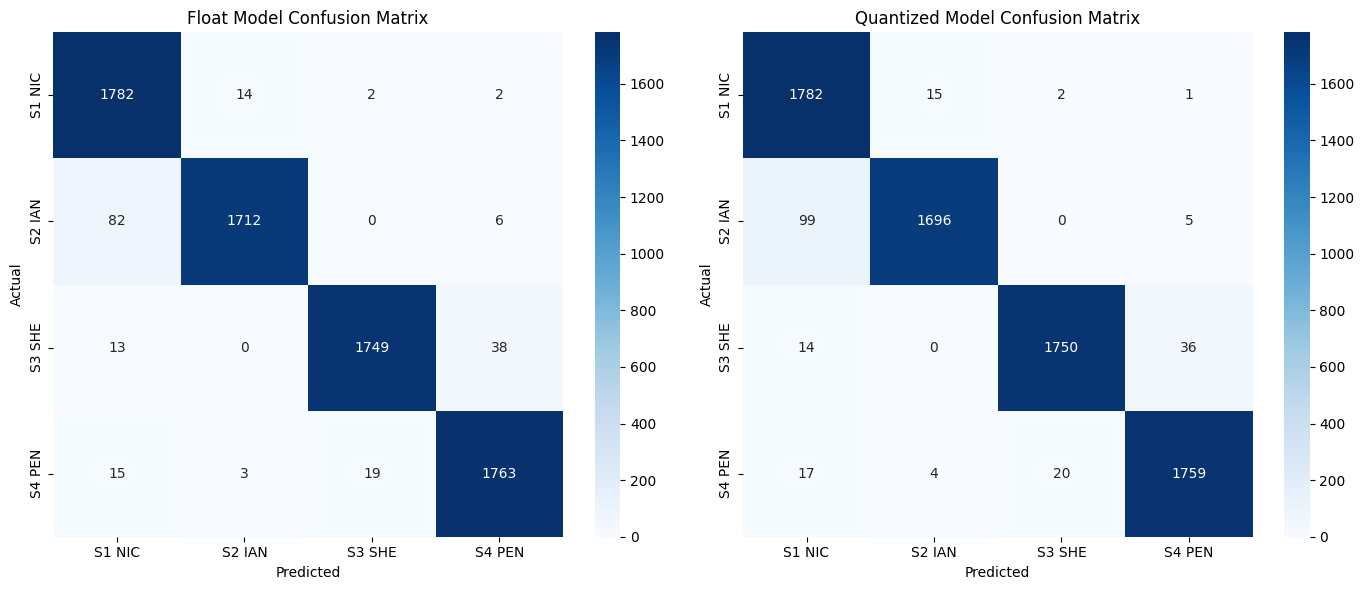


Classification Report – Quantized Model
------------------------------------------------------------
              precision    recall  f1-score   support

      S1 NIC       0.93      0.99      0.96      1800
      S2 IAN       0.99      0.94      0.97      1800
      S3 SHE       0.99      0.97      0.98      1800
      S4 PEN       0.98      0.98      0.98      1800

    accuracy                           0.97      7200
   macro avg       0.97      0.97      0.97      7200
weighted avg       0.97      0.97      0.97      7200



In [56]:
# ────────────────────────────────────────────────────────────────
#  Run evaluation on both models
# ────────────────────────────────────────────────────────────────

print("Evaluating FLOAT model...")
y_true_float, y_pred_float = evaluate_litert_model(
    FLOAT_MODEL_PATH, test_ds, max_samples=MAX_SAMPLES
)

print("\nEvaluating QUANTIZED model...")
y_true_quant, y_pred_quant = evaluate_litert_model(
    QUANT_MODEL_PATH, test_ds, max_samples=MAX_SAMPLES
)

# ────────────────────────────────────────────────────────────────
#  Comparison & Visualization
# ────────────────────────────────────────────────────────────────

# Accuracy
acc_float = np.mean(y_true_float == y_pred_float)
acc_quant = np.mean(y_true_quant == y_pred_quant)

print("\n" + "="*60)
print("MODEL ACCURACY COMPARISON")
print("="*60)
print(f"Float model    : {acc_float:.4f}  ({acc_float*100:.2f}%)")
print(f"Quantized model: {acc_quant:.4f}  ({acc_quant*100:.2f}%)")
print(f"Accuracy drop  : {(acc_float - acc_quant)*100:.2f}%")

# Confusion Matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Float model CM
cm_float = confusion_matrix(y_true_float, y_pred_float)
sns.heatmap(cm_float, annot=True, fmt='g', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Float Model Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Quantized model CM
cm_quant = confusion_matrix(y_true_quant, y_pred_quant)
sns.heatmap(cm_quant, annot=True, fmt='g', cmap='Blues', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title('Quantized Model Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Detailed classification report (for quantized model – most interesting)
print("\nClassification Report – Quantized Model")
print("-"*60)
print(classification_report(y_true_quant, y_pred_quant, target_names=class_names))

# Optional: also show for float model if you want
# print("\nClassification Report – Float Model")
# print(classification_report(y_true_float, y_pred_float, target_names=class_names))

In [34]:
print("\nEvaluating QUANTIZED model...")
y_true_quant, y_pred_quant = evaluate_litert_model(
    QUANT_MODEL_PATH, test_ds, max_samples=MAX_SAMPLES
)


Evaluating QUANTIZED model...
Model: CNN model/quantized_tensorflowlite_cnn.tflite
Input shape: [ 1 32 32  1]
Output shape: [1 4]
--------------------------------------------------
Processed 7200 samples...
Evaluated 7200 samples


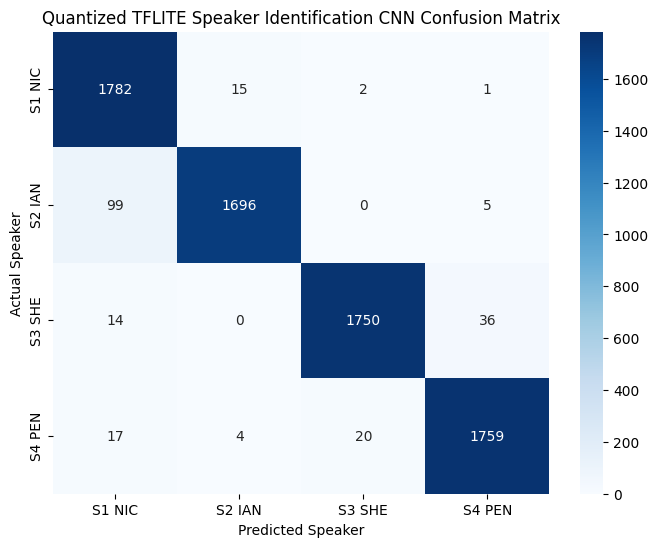

              precision    recall  f1-score   support

      S1 NIC       0.93      0.99      0.96      1800
      S2 IAN       0.99      0.94      0.97      1800
      S3 SHE       0.99      0.97      0.98      1800
      S4 PEN       0.98      0.98      0.98      1800

    accuracy                           0.97      7200
   macro avg       0.97      0.97      0.97      7200
weighted avg       0.97      0.97      0.97      7200



In [35]:
# 2. Create the confusion matrix
cm = confusion_matrix(y_true_quant, y_pred_quant)

# 3. Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.xlabel('Predicted Speaker')
plt.ylabel('Actual Speaker')
plt.title('Quantized TFLITE Speaker Identification CNN Confusion Matrix')
plt.savefig("quant_cnn_tflite_cm.png", dpi=300)
plt.show()

# 4. Print detailed report (Precision, Recall, F1-Score)
print(classification_report(y_true_quant, y_pred_quant, target_names=class_names))

In [57]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen
# Ensure that if any ops can't be quantized, the converter throws an error
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
# Set the input and output tensors to uint8 (APIs added in r2.3)
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

int_tflite_model_quant = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpm3jzil_l\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpm3jzil_l\assets


Saved artifact at 'C:\Users\User\AppData\Local\Temp\tmpm3jzil_l'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  2719035660752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035661520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035662288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035660560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035661904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035661712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035662480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2719035663248: TensorSpec(shape=(), dtype=tf.resource, name=None)


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [58]:
interpreter = tf.lite.Interpreter(model_content=int_tflite_model_quant)
input_type = interpreter.get_input_details()[0]['dtype']
print('input: ', input_type)
output_type = interpreter.get_output_details()[0]['dtype']
print('output: ', output_type)

input:  <class 'numpy.uint8'>
output:  <class 'numpy.uint8'>


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [59]:
tflite_path = os.path.join(save_dir, 'full_int_quantized_tensorflowlite_cnn.tflite')

with open(tflite_path, 'wb') as f:
    f.write(int_tflite_model_quant)

In [60]:
# with open('full_int_quantized_tensorflowlite_cnn.tflite', 'wb') as f:
#   f.write(int_tflite_model_quant)

In [61]:
print(f"Integer Quantized Tensorflowlite model size: {len(int_tflite_model_quant):,} bytes ({len(int_tflite_model_quant)/1024:.2f} KB)")

Integer Quantized Tensorflowlite model size: 144,184 bytes (140.80 KB)


In [62]:
INT_QUANT_MODEL_PATH   = 'CNN model/full_int_quantized_tensorflowlite_cnn.tflite'

In [63]:
def evaluate_litert_model_int(model_path, test_dataset, max_samples=None):
    """
    Evaluate a .tflite / LiteRT model using signature runner.
    Returns: y_true, y_pred (as numpy arrays)
    """

    # Load model
    interpreter = Interpreter(model_path=model_path)
    
    # Get available signatures (usually 'serving_default')
    signatures = interpreter.get_signature_list()
    if 'serving_default' not in signatures:
        raise ValueError("Model does not have 'serving_default' signature")
    
    # Get runner for default inference signature
    runner = interpreter.get_signature_runner('serving_default')
    
    # Get input/output tensor names (usually 'keras_tensor' / 'input_...' and 'output_...')
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    print(f"Model: {model_path}")
    print("Input shape:", input_details[0]['shape'])
    print("Output shape:", output_details[0]['shape'])
    print("-" * 50)

    y_true = []
    y_pred = []
    total_processed = 0

    for images, labels in test_dataset:
        if max_samples is not None and total_processed >= max_samples:
            break

        batch_size = images.shape[0]

        # Run batched inference using signature runner
        # Input key is usually 'keras_tensor' or 'input_1' — adjust if needed
        inputs = {'keras_tensor': np.round(images.numpy() * 255).astype(np.uint8)}   # ← most common key in recent exports
        outputs = runner(**inputs)
        
        # Output key is usually 'output_0' or 'dense' — adjust based on your model
        predictions = outputs['output_0']           # shape: (batch_size, num_classes)

        # Convert to class indices
        true_classes = np.argmax(labels.numpy(), axis=1)
        pred_classes = np.argmax(predictions, axis=1)

        y_true.extend(true_classes)
        y_pred.extend(pred_classes)

        total_processed += batch_size
        print(f"Processed {total_processed} samples...", end='\r')

    print(f"\nEvaluated {len(y_true)} samples")
    return np.array(y_true), np.array(y_pred)


Evaluating INT QUANTIZED model...
Model: CNN model/full_int_quantized_tensorflowlite_cnn.tflite
Input shape: [ 1 32 32  1]
Output shape: [1 4]
--------------------------------------------------
Processed 7200 samples...
Evaluated 7200 samples

Evaluating QUANTIZED model...
Model: CNN model/quantized_tensorflowlite_cnn.tflite
Input shape: [ 1 32 32  1]
Output shape: [1 4]
--------------------------------------------------
Processed 7200 samples...
Evaluated 7200 samples

MODEL ACCURACY COMPARISON
INT QUANTIZED model    : 0.9707  (97.07%)
Quantized model: 0.9704  (97.04%)
Accuracy drop  : 0.03%


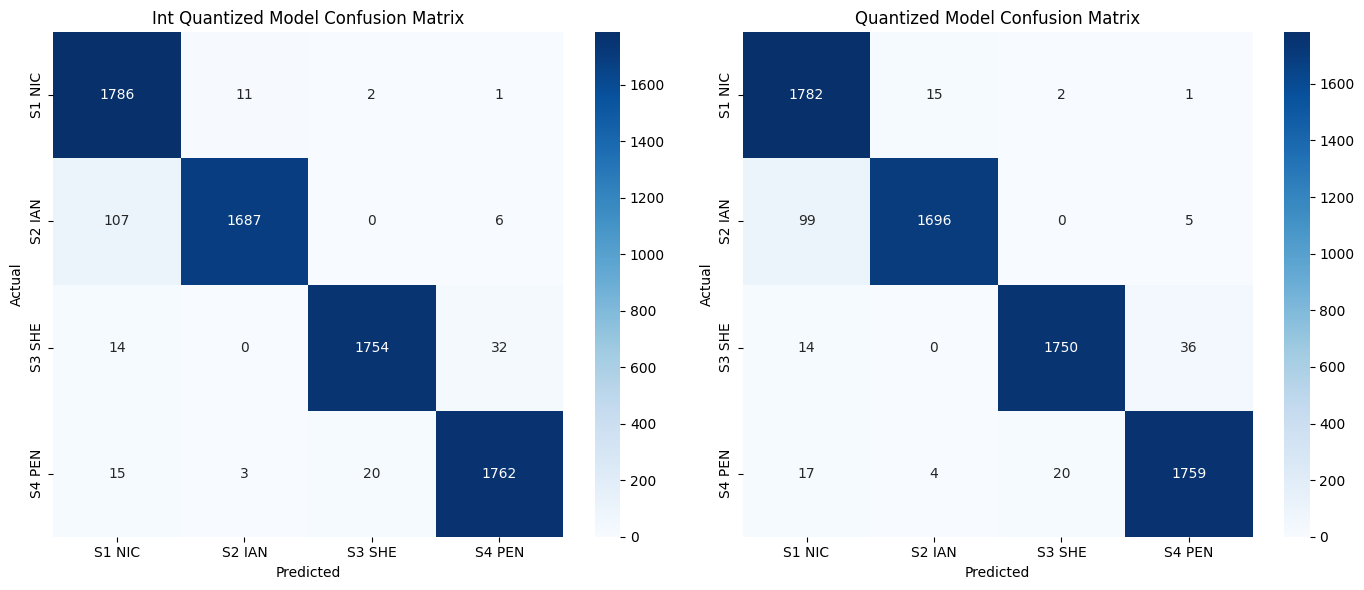


Classification Report – Int Quantized Model
------------------------------------------------------------
              precision    recall  f1-score   support

      S1 NIC       0.93      0.99      0.96      1800
      S2 IAN       0.99      0.94      0.96      1800
      S3 SHE       0.99      0.97      0.98      1800
      S4 PEN       0.98      0.98      0.98      1800

    accuracy                           0.97      7200
   macro avg       0.97      0.97      0.97      7200
weighted avg       0.97      0.97      0.97      7200



In [64]:
# ────────────────────────────────────────────────────────────────
#  Run evaluation on both models
# ────────────────────────────────────────────────────────────────

print("Evaluating INT QUANTIZED model...")
y_true_float, y_pred_float = evaluate_litert_model_int(
    INT_QUANT_MODEL_PATH, test_ds, max_samples=MAX_SAMPLES
)

print("\nEvaluating QUANTIZED model...")
y_true_quant, y_pred_quant = evaluate_litert_model(
    QUANT_MODEL_PATH, test_ds, max_samples=MAX_SAMPLES
)

# ────────────────────────────────────────────────────────────────
#  Comparison & Visualization
# ────────────────────────────────────────────────────────────────

# Accuracy
acc_float = np.mean(y_true_float == y_pred_float)
acc_quant = np.mean(y_true_quant == y_pred_quant)

print("\n" + "="*60)
print("MODEL ACCURACY COMPARISON")
print("="*60)
print(f"INT QUANTIZED model    : {acc_float:.4f}  ({acc_float*100:.2f}%)")
print(f"Quantized model: {acc_quant:.4f}  ({acc_quant*100:.2f}%)")
print(f"Accuracy drop  : {(acc_float - acc_quant)*100:.2f}%")

# Confusion Matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Float model CM
cm_float = confusion_matrix(y_true_float, y_pred_float)
sns.heatmap(cm_float, annot=True, fmt='g', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Int Quantized Model Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Quantized model CM
cm_quant = confusion_matrix(y_true_quant, y_pred_quant)
sns.heatmap(cm_quant, annot=True, fmt='g', cmap='Blues', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title('Quantized Model Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Detailed classification report (for quantized model – most interesting)
print("\nClassification Report – Int Quantized Model")
print("-"*60)
print(classification_report(y_true_float, y_pred_float, target_names=class_names))

# Optional: also show for float model if you want
# print("\nClassification Report – Float Model")
# print(classification_report(y_true_float, y_pred_float, target_names=class_names))

Expected input shape: [ 1 32 32  1]
Expected input dtype: float32
Input shape before inference: (1, 32, 32, 1)
Input dtype before inference: float32

Prediction: S4 PEN
Confidence: 99.61%
Raw logits / probabilities: [0.         0.         0.         0.99609375]


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


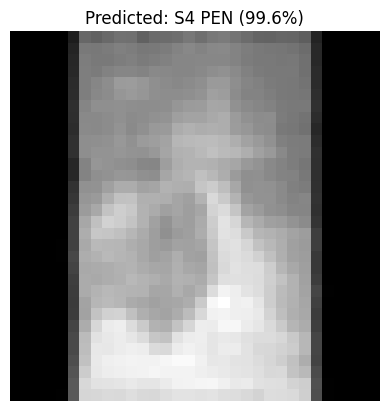

In [65]:
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────
#  1. Paths & settings – change these
# ────────────────────────────────────────────────

MODEL_PATH = "CNN model/quantized_tensorflowlite_cnn.tflite"          # your float or quantized .tflite file
IMAGE_PATH = "imds32/S4 PEN/BM_S4_BUS_Sound 0004_mel.png"   # or .jpg, .png, etc.

# From your earlier code – adjust if different
IMG_HEIGHT = 32
IMG_WIDTH  = 32
CLASS_NAMES = class_names         # e.g. ['class0', 'class1', 'class2', 'class3']

# ────────────────────────────────────────────────
#  2. Load and prepare the TFLite interpreter
# ────────────────────────────────────────────────

interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

# Get input & output details
input_details  = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

print("Expected input shape:", input_details['shape'])
print("Expected input dtype:", input_details['dtype'].__name__)

# ────────────────────────────────────────────────
#  3. Load & preprocess ONE image
# ────────────────────────────────────────────────

# Load image with PIL
img = Image.open(IMAGE_PATH)

# Convert to numpy array
img_array = np.array(img)                   # shape: (32, 32)
img_input = img_array
img_input_og = img_input
# Add channel dimension → (32, 32, 1)
img_array = np.expand_dims(img_array, axis=-1)

# Add batch dimension → most models want (1, 32, 32, 1)
img_input = np.expand_dims(img_array, axis=0)   # shape: (1, 32, 32, 1)

# Important: match the expected dtype & range
expected_dtype = input_details['dtype']

if expected_dtype == np.float32:
    # Most float models expect [0, 1]
    img_input = img_input.astype(np.float32) / 255.0

elif expected_dtype == np.uint8:
    # Full uint8 quantized → expect [0–255]
    img_input = img_input.astype(np.uint8)               # already 0–255 from PIL

elif expected_dtype == np.int8:
    # Full int8 quantized → usually feed float [0,1], runtime quantizes
    # OR feed already quantized int8 values
    img_input = img_input.astype(np.float32) / 255.0
    # If model wants pre-quantized int8 → use quantization params:
    # quant = input_details['quantization_parameters']
    # scale, zp = quant['scales'][0], quant['zero_points'][0]
    # img_input = np.round(img_input / scale + zp).clip(-128, 127).astype(np.int8)

else:
    raise ValueError(f"Unexpected input dtype: {expected_dtype}")

# Quick check
print("Input shape before inference:", img_input.shape)
print("Input dtype before inference:", img_input.dtype)

# ────────────────────────────────────────────────
#  4. Run inference
# ────────────────────────────────────────────────

interpreter.set_tensor(input_details['index'], img_input)
interpreter.invoke()

# Get output
output_data = interpreter.get_tensor(output_details['index'])[0]  # shape: (num_classes,)

# If output is quantized (int8/uint8) → dequantize
if output_details['dtype'] in (np.int8, np.uint8):
    quant = output_details['quantization_parameters']
    scale, zp = quant['scales'][0], quant['zero_points'][0]
    output_data = (output_data.astype(np.float32) - zp) * scale

# Get predicted class
predicted_idx = np.argmax(output_data)
predicted_label = CLASS_NAMES[predicted_idx]
confidence = output_data[predicted_idx] * 100   # rough %

print(f"\nPrediction: {predicted_label}")
print(f"Confidence: {confidence:.2f}%")
print("Raw logits / probabilities:", output_data)

# ────────────────────────────────────────────────
#  5. Optional: Show the image + prediction
# ────────────────────────────────────────────────

plt.imshow(img_array.squeeze(), cmap='gray')
plt.title(f"Predicted: {predicted_label} ({confidence:.1f}%)")
plt.axis('off')
plt.show()

In [54]:
print(img_input)

[[[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]]]


In [55]:
print(img_array)

[[[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 ...

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]]


In [56]:
print(img_input_og)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
from ai_edge_litert.interpreter import Interpreter
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

test_dataset_path = "FULL 16K 32"

image_height, image_width = 32, 32
batch_size = 128

test_ds = tf.keras.utils.image_dataset_from_directory(
  test_dataset_path,
  seed=456,
  image_size=(image_height, image_width),
  batch_size=batch_size,
  labels="inferred",
  label_mode="categorical",
  color_mode="grayscale",)

# Path to your LiteRT / TFLite model files
FLOAT_MODEL_PATH   = 'tensorflowlite_mlp.tflite'              # original float32 model
QUANT_MODEL_PATH   = 'quantized_tensorflowlite_mlp.tflite'         # your quantized model

# Assume test_ds is already created (from image_dataset_from_directory)
# and class_names = test_ds.class_names is available

# Number of samples to evaluate (for speed; set to None to use full test set)
MAX_SAMPLES = None

In [ ]:
# ────────────────────────────────────────────────────────────────
#  Helper function to evaluate one LiteRT model
# ────────────────────────────────────────────────────────────────
def evaluate_litert_model(model_path, test_dataset, max_samples=None):
    """
    Evaluate a .tflite / LiteRT model using signature runner.
    Returns: y_true, y_pred (as numpy arrays)
    """

    # Load model
    interpreter = Interpreter(model_path=model_path)
    
    # Get available signatures (usually 'serving_default')
    signatures = interpreter.get_signature_list()
    if 'serving_default' not in signatures:
        raise ValueError("Model does not have 'serving_default' signature")
    
    # Get runner for default inference signature
    runner = interpreter.get_signature_runner('serving_default')
    
    # Get input/output tensor names (usually 'keras_tensor' / 'input_...' and 'output_...')
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    print(f"Model: {model_path}")
    print("Input shape:", input_details[0]['shape'])
    print("Output shape:", output_details[0]['shape'])
    print("-" * 50)

    y_true = []
    y_pred = []
    total_processed = 0

    for images, labels in test_dataset:
        if max_samples is not None and total_processed >= max_samples:
            break

        batch_size = images.shape[0]

        # Run batched inference using signature runner
        # Input key is usually 'keras_tensor' or 'input_1' — adjust if needed
        inputs = {'keras_tensor': images.numpy()}   # ← most common key in recent exports
        outputs = runner(**inputs)
        
        # Output key is usually 'output_0' or 'dense' — adjust based on your model
        predictions = outputs['output_0']           # shape: (batch_size, num_classes)

        # Convert to class indices
        true_classes = np.argmax(labels.numpy(), axis=1)
        pred_classes = np.argmax(predictions, axis=1)

        y_true.extend(true_classes)
        y_pred.extend(pred_classes)

        total_processed += batch_size
        print(f"Processed {total_processed} samples...", end='\r')

    print(f"\nEvaluated {len(y_true)} samples")
    return np.array(y_true), np.array(y_pred)


In [ ]:
# ────────────────────────────────────────────────────────────────
#  Run evaluation on both models
# ────────────────────────────────────────────────────────────────

print("Evaluating FLOAT model...")
y_true_float, y_pred_float = evaluate_litert_model(
    FLOAT_MODEL_PATH, test_ds, max_samples=MAX_SAMPLES
)

print("\nEvaluating QUANTIZED model...")
y_true_quant, y_pred_quant = evaluate_litert_model(
    QUANT_MODEL_PATH, test_ds, max_samples=MAX_SAMPLES
)

# ────────────────────────────────────────────────────────────────
#  Comparison & Visualization
# ────────────────────────────────────────────────────────────────

# Accuracy
acc_float = np.mean(y_true_float == y_pred_float)
acc_quant = np.mean(y_true_quant == y_pred_quant)

print("\n" + "="*60)
print("MODEL ACCURACY COMPARISON")
print("="*60)
print(f"Float model    : {acc_float:.4f}  ({acc_float*100:.2f}%)")
print(f"Quantized model: {acc_quant:.4f}  ({acc_quant*100:.2f}%)")
print(f"Accuracy drop  : {(acc_float - acc_quant)*100:.2f}%")

# Confusion Matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Float model CM
cm_float = confusion_matrix(y_true_float, y_pred_float)
sns.heatmap(cm_float, annot=True, fmt='g', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Float Model Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Quantized model CM
cm_quant = confusion_matrix(y_true_quant, y_pred_quant)
sns.heatmap(cm_quant, annot=True, fmt='g', cmap='Blues', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title('Quantized Model Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Detailed classification report (for quantized model – most interesting)
print("\nClassification Report – FULL DATASET Quantized Model")
print("-"*60)
print(classification_report(y_true_quant, y_pred_quant, target_names=class_names))

# Optional: also show for float model if you want
# print("\nClassification Report – Float Model")
# print(classification_report(y_true_float, y_pred_float, target_names=class_names))

In [ ]:
INT_QUANT_MODEL_PATH   = 'full_int_quantized_tensorflowlite_cnn.tflite'

In [ ]:
def evaluate_litert_model_int(model_path, test_dataset, max_samples=None):
    """
    Evaluate a .tflite / LiteRT model using signature runner.
    Returns: y_true, y_pred (as numpy arrays)
    """

    # Load model
    interpreter = Interpreter(model_path=model_path)
    
    # Get available signatures (usually 'serving_default')
    signatures = interpreter.get_signature_list()
    if 'serving_default' not in signatures:
        raise ValueError("Model does not have 'serving_default' signature")
    
    # Get runner for default inference signature
    runner = interpreter.get_signature_runner('serving_default')
    
    # Get input/output tensor names (usually 'keras_tensor' / 'input_...' and 'output_...')
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    print(f"Model: {model_path}")
    print("Input shape:", input_details[0]['shape'])
    print("Output shape:", output_details[0]['shape'])
    print("-" * 50)

    y_true = []
    y_pred = []
    total_processed = 0

    for images, labels in test_dataset:
        if max_samples is not None and total_processed >= max_samples:
            break

        batch_size = images.shape[0]

        # Run batched inference using signature runner
        # Input key is usually 'keras_tensor' or 'input_1' — adjust if needed
        inputs = {'keras_tensor': np.round(images.numpy() * 255).astype(np.uint8)}   # ← most common key in recent exports
        outputs = runner(**inputs)
        
        # Output key is usually 'output_0' or 'dense' — adjust based on your model
        predictions = outputs['output_0']           # shape: (batch_size, num_classes)

        # Convert to class indices
        true_classes = np.argmax(labels.numpy(), axis=1)
        pred_classes = np.argmax(predictions, axis=1)

        y_true.extend(true_classes)
        y_pred.extend(pred_classes)

        total_processed += batch_size
        print(f"Processed {total_processed} samples...", end='\r')

    print(f"\nEvaluated {len(y_true)} samples")
    return np.array(y_true), np.array(y_pred)


In [ ]:
# ────────────────────────────────────────────────────────────────
#  Run evaluation on both models
# ────────────────────────────────────────────────────────────────

print("Evaluating INT QUANTIZED model...")
y_true_float, y_pred_float = evaluate_litert_model_int(
    INT_QUANT_MODEL_PATH, test_ds, max_samples=MAX_SAMPLES
)

print("\nEvaluating QUANTIZED model...")
y_true_quant, y_pred_quant = evaluate_litert_model(
    QUANT_MODEL_PATH, test_ds, max_samples=MAX_SAMPLES
)

# ────────────────────────────────────────────────────────────────
#  Comparison & Visualization
# ────────────────────────────────────────────────────────────────

# Accuracy
acc_float = np.mean(y_true_float == y_pred_float)
acc_quant = np.mean(y_true_quant == y_pred_quant)

print("\n" + "="*60)
print("MODEL ACCURACY COMPARISON")
print("="*60)
print(f"INT QUANTIZED model    : {acc_float:.4f}  ({acc_float*100:.2f}%)")
print(f"Quantized model: {acc_quant:.4f}  ({acc_quant*100:.2f}%)")
print(f"Accuracy drop  : {(acc_float - acc_quant)*100:.2f}%")

# Confusion Matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Float model CM
cm_float = confusion_matrix(y_true_float, y_pred_float)
sns.heatmap(cm_float, annot=True, fmt='g', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Int Quantized Model Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Quantized model CM
cm_quant = confusion_matrix(y_true_quant, y_pred_quant)
sns.heatmap(cm_quant, annot=True, fmt='g', cmap='Blues', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title('Quantized Model Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Detailed classification report (for quantized model – most interesting)
print("\nClassification Report – Int Quantized Model")
print("-"*60)
print(classification_report(y_true_float, y_pred_float, target_names=class_names))

# Optional: also show for float model if you want
# print("\nClassification Report – Float Model")
# print(classification_report(y_true_float, y_pred_float, target_names=class_names))